# 01 Data Exploration

In this notebook, we load and inspect the WESAD dataset. We begin with one subject and explore the physiological signals, labels, and basic signal visualizations.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "WESAD"

print("Dataset path:", DATA_DIR)
print("Does dataset folder exist?", DATA_DIR.exists())

Dataset path: ..\data\WESAD
Does dataset folder exist? True


In [3]:
subject_folders = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

print("Number of subject folders:", len(subject_folders))
print("Subjects:")

for folder in subject_folders:
    print(folder.name)

Number of subject folders: 15
Subjects:
S10
S11
S13
S14
S15
S16
S17
S2
S3
S4
S5
S6
S7
S8
S9


In [4]:
subject_id = "S2"
subject_file = DATA_DIR / subject_id / f"{subject_id}.pkl"

print("Subject file:", subject_file)
print("File exists?", subject_file.exists())

Subject file: ..\data\WESAD\S2\S2.pkl
File exists? True


In [5]:
with open(subject_file, "rb") as file:
    subject_data = pickle.load(file, encoding="latin1")

print(type(subject_data))
print(subject_data.keys())

<class 'dict'>
dict_keys(['signal', 'label', 'subject'])


In [6]:
print("Subject:", subject_data["subject"])

print("\nMain keys:")
print(subject_data.keys())

print("\nSignal keys:")
print(subject_data["signal"].keys())

print("\nChest signal keys:")
print(subject_data["signal"]["chest"].keys())

print("\nWrist signal keys:")
print(subject_data["signal"]["wrist"].keys())

print("\nLabel shape:")
print(subject_data["label"].shape)

Subject: S2

Main keys:
dict_keys(['signal', 'label', 'subject'])

Signal keys:
dict_keys(['chest', 'wrist'])

Chest signal keys:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])

Wrist signal keys:
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])

Label shape:
(4255300,)


In [7]:
chest = subject_data["signal"]["chest"]
wrist = subject_data["signal"]["wrist"]
labels = subject_data["label"]

print("Chest signals:")
for signal_name, signal_values in chest.items():
    print(signal_name, signal_values.shape)

print("\nWrist signals:")
for signal_name, signal_values in wrist.items():
    print(signal_name, signal_values.shape)

print("\nLabels:")
print(labels.shape)

Chest signals:
ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)

Wrist signals:
ACC (194528, 3)
BVP (389056, 1)
EDA (24316, 1)
TEMP (24316, 1)

Labels:
(4255300,)


In [8]:
unique_labels, counts = np.unique(labels, return_counts=True)

label_summary = pd.DataFrame({
    "label": unique_labels,
    "count": counts
})

label_summary

,label,count
0,0,2142701
1,1,800800
2,2,430500
3,3,253400
4,4,537599
5,6,45500
6,7,44800


In [9]:
label_names = {
    0: "Undefined / Transient",
    1: "Baseline / Neutral",
    2: "Stress",
    3: "Amusement",
    4: "Meditation"
}

label_summary["label_name"] = label_summary["label"].map(label_names)
label_summary

,label,count,label_name
0,0,2142701,Undefined / Transient
1,1,800800,Baseline / Neutral
2,2,430500,Stress
3,3,253400,Amusement
4,4,537599,Meditation
5,6,45500,NaN
6,7,44800,NaN


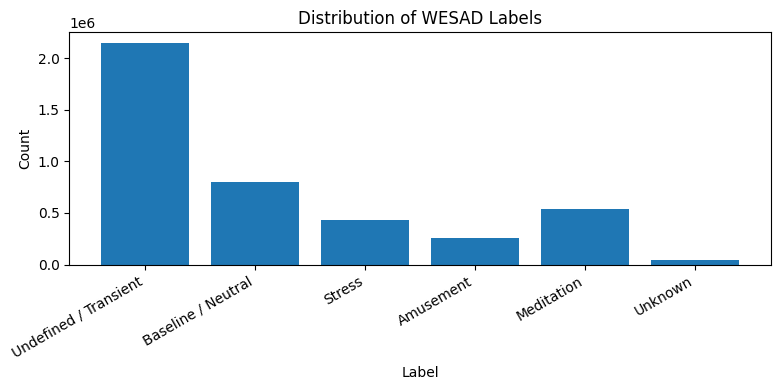

In [11]:
# Create a copy so we do not modify the original label_summary accidentally
plot_df = label_summary.copy()

# Convert label names to string and replace missing values with "Unknown"
plot_df["label_name"] = plot_df["label_name"].fillna("Unknown").astype(str)

# Make sure count is numeric
plot_df["count"] = pd.to_numeric(plot_df["count"], errors="coerce").fillna(0)

# Plot the label distribution
plt.figure(figsize=(8, 4))
plt.bar(plot_df["label_name"], plot_df["count"])
plt.xticks(rotation=30, ha="right")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of WESAD Labels")
plt.tight_layout()
plt.show()

In [12]:
ecg = chest["ECG"].reshape(-1)
eda = chest["EDA"].reshape(-1)
emg = chest["EMG"].reshape(-1)
temp = chest["Temp"].reshape(-1)
resp = chest["Resp"].reshape(-1)

print("ECG shape:", ecg.shape)
print("EDA shape:", eda.shape)
print("EMG shape:", emg.shape)
print("Temperature shape:", temp.shape)
print("Respiration shape:", resp.shape)
print("Labels shape:", labels.shape)

ECG shape: (4255300,)
EDA shape: (4255300,)
EMG shape: (4255300,)
Temperature shape: (4255300,)
Respiration shape: (4255300,)
Labels shape: (4255300,)


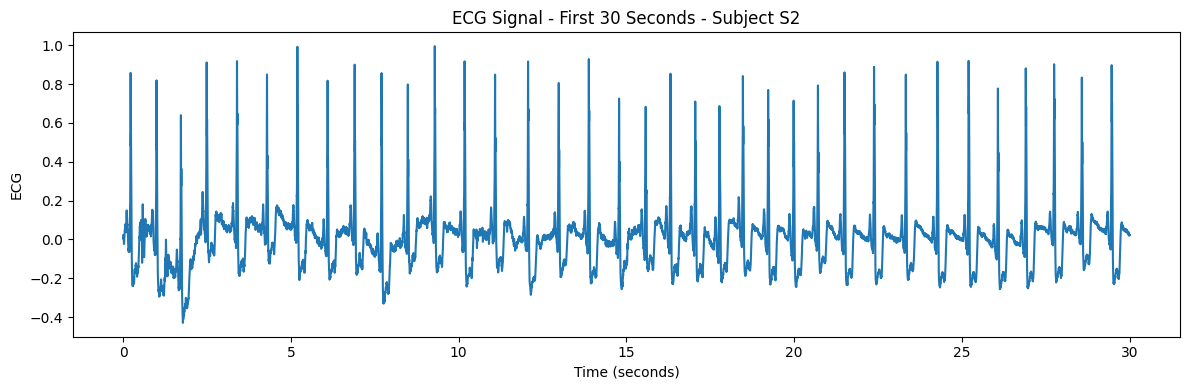

In [13]:
fs_chest = 700

start_sec = 0
duration_sec = 30

start_idx = start_sec * fs_chest
end_idx = (start_sec + duration_sec) * fs_chest

time_axis = np.arange(start_idx, end_idx) / fs_chest

plt.figure(figsize=(12, 4))
plt.plot(time_axis, ecg[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title(f"ECG Signal - First {duration_sec} Seconds - Subject {subject_id}")
plt.tight_layout()
plt.show()

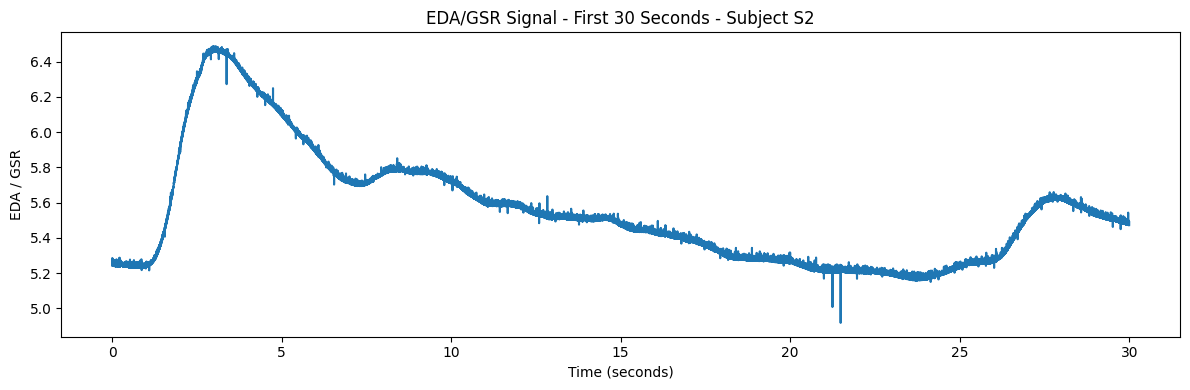

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(time_axis, eda[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("EDA / GSR")
plt.title(f"EDA/GSR Signal - First {duration_sec} Seconds - Subject {subject_id}")
plt.tight_layout()
plt.show()

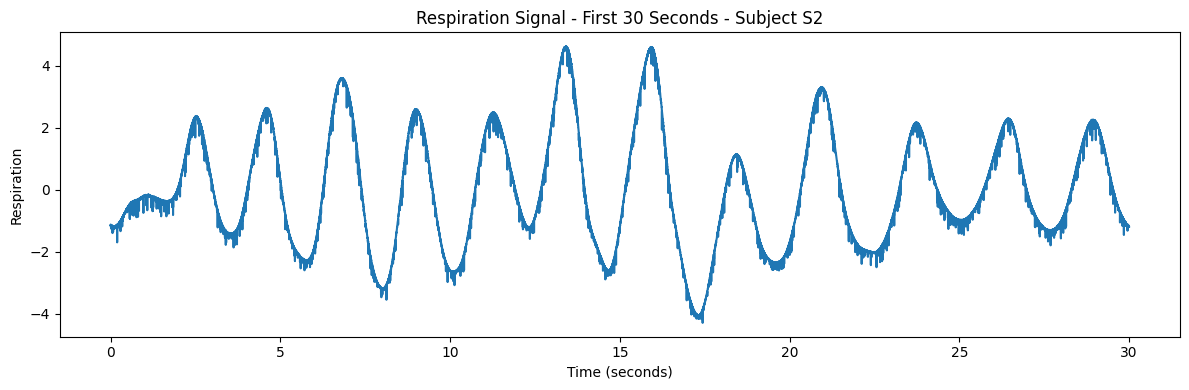

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(time_axis, resp[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("Respiration")
plt.title(f"Respiration Signal - First {duration_sec} Seconds - Subject {subject_id}")
plt.tight_layout()
plt.show()

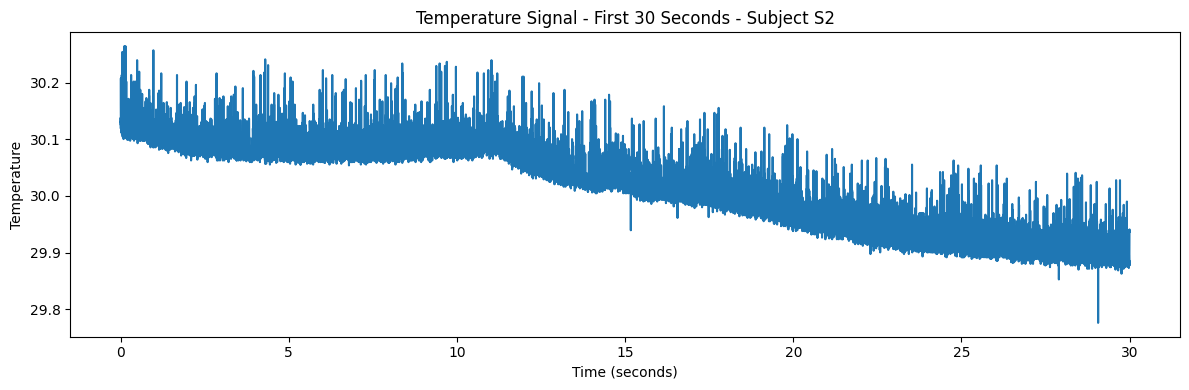

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(time_axis, temp[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("Temperature")
plt.title(f"Temperature Signal - First {duration_sec} Seconds - Subject {subject_id}")
plt.tight_layout()
plt.show()

In [17]:
stress_indices = np.where(labels == 2)[0]

print("Number of stress samples:", len(stress_indices))
print("First stress index:", stress_indices[0])
print("Last stress index:", stress_indices[-1])

Number of stress samples: 430500
First stress index: 1591482
Last stress index: 2021981


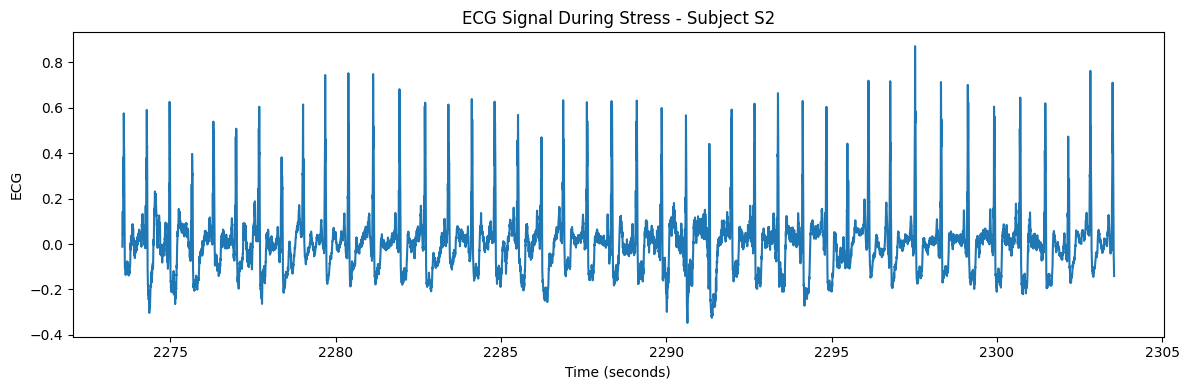

In [18]:
start_idx = stress_indices[0]
end_idx = start_idx + duration_sec * fs_chest

time_axis = np.arange(start_idx, end_idx) / fs_chest

plt.figure(figsize=(12, 4))
plt.plot(time_axis, ecg[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title(f"ECG Signal During Stress - Subject {subject_id}")
plt.tight_layout()
plt.show()

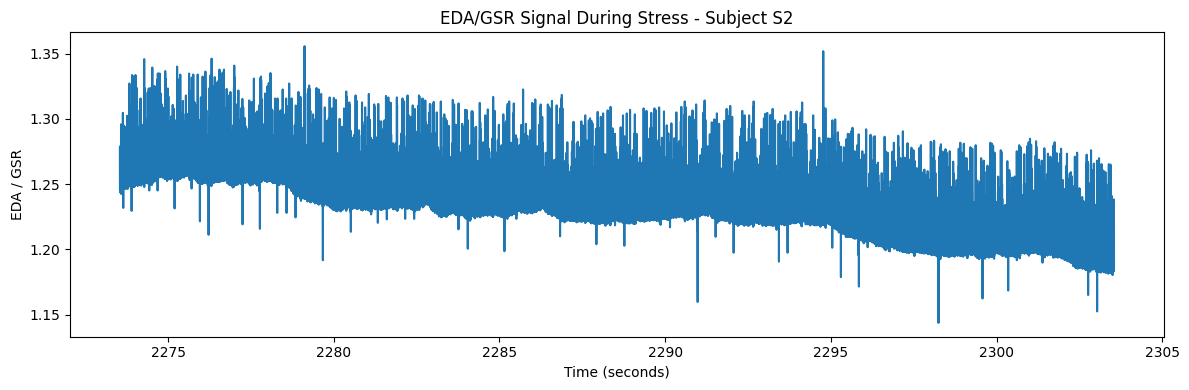

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(time_axis, eda[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("EDA / GSR")
plt.title(f"EDA/GSR Signal During Stress - Subject {subject_id}")
plt.tight_layout()
plt.show()

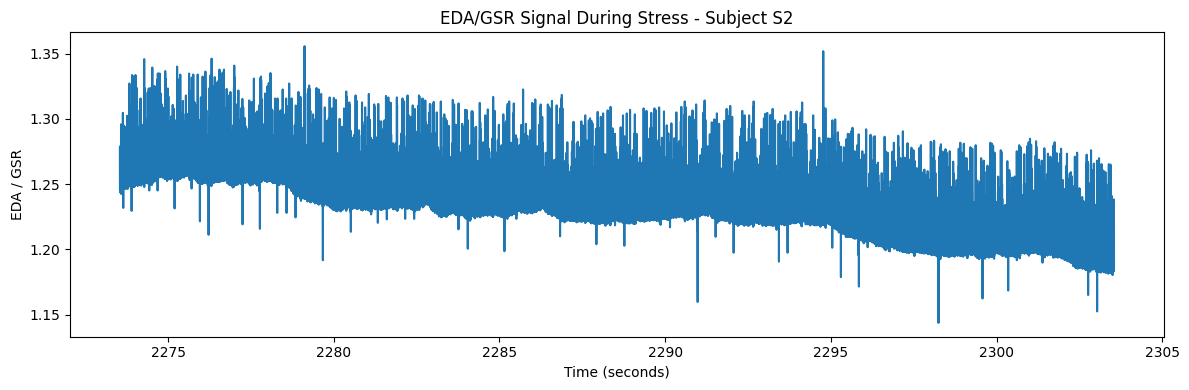

Saved plot to: ..\results\eda_stress_subject_S2.png


In [20]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

plt.figure(figsize=(12, 4))
plt.plot(time_axis, eda[start_idx:end_idx])
plt.xlabel("Time (seconds)")
plt.ylabel("EDA / GSR")
plt.title(f"EDA/GSR Signal During Stress - Subject {subject_id}")
plt.tight_layout()

output_path = RESULTS_DIR / "eda_stress_subject_S2.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved plot to:", output_path)